In [1]:
import sys
sys.path.append('../..')
from hydra import initialize, compose
import numpy as np
from hydra.utils import instantiate
import matplotlib.pyplot as plt

from tools_and_examples.graphic_tools import rename_labels


# NL Function sampling

## $V_{nl,mono}$

In [2]:
# To keep everything clean we use hydra for HPs.
with initialize(version_base=None, config_path="../../config/"):
    cfg = compose(config_name='generate_dataset.yaml')

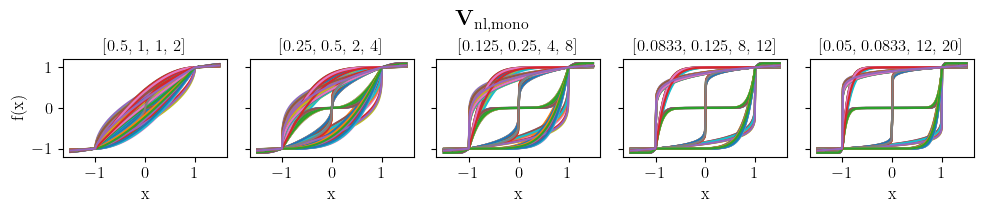

In [4]:
fig, axs  = plt.subplots(1, 5, figsize=(10, 2),sharey=True)
power_dist = [
    [0.5, 1, 1, 2],
    [0.25, 0.5, 2, 4],
    [0.125, 0.25, 4, 8],
    [0.0833, 0.125, 8, 12],
    [0.05, 0.0833, 12, 20],
]
for i, x in enumerate(power_dist):
    cfg.generator.lagged.nl_sampler.which_power_dist = "all"

    sampler = instantiate(cfg["generator"]["lagged"]["nl_sampler"], nl_mode="power_set", power_dist= x)
    funcs, names = sampler.sample_nl_relationships(np.ones((5,5,5)), nl_proba=1, nl_mask=None)
    for v in range(funcs.shape[0]):
        for w in range(funcs.shape[1]):
            for z in range(funcs.shape[2]):
                axs[i].plot(np.arange(-1.5,1.5,0.01),[funcs[v][w][z](x) for x in np.arange(-1.5,1.5,0.01)])
    axs[i].set_title(f"{x}",fontsize=12)
    axs[i].set_xlabel("x")
    
axs[0].set_ylabel("f(x)")
plt.tight_layout()

fig.suptitle(rename_labels["nl_power"], fontsize=16, y=1.05)

plt.savefig("../img/power_violation.pdf", bbox_inches="tight")

## $V_{nl,trend}$

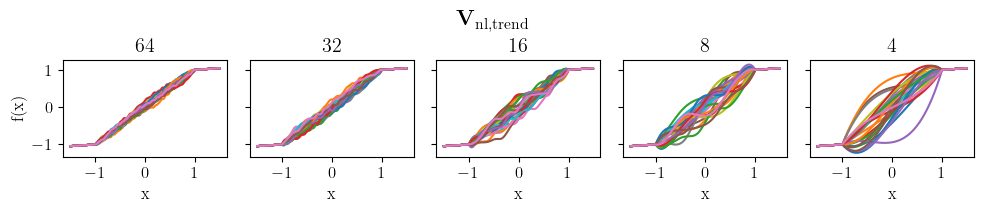

In [7]:
fig, axs  = plt.subplots(1, 5, figsize=(10, 2),sharey=True)
for i, x in enumerate([64,32,16,8,4]):
    sampler = instantiate(cfg["generator"]["lagged"]["nl_sampler"], nl_mode="splines", spline_samples= x)
    funcs, names = sampler.sample_nl_relationships(np.ones((3,3,3)), nl_proba=1, nl_mask=None)
    for v in range(funcs.shape[0]):
        for w in range(funcs.shape[1]):
            for z in range(funcs.shape[2]):
                axs[i].plot(np.arange(-1.5,1.5,0.01),[funcs[v][w][z](x) for x in np.arange(-1.5,1.5,0.01)])
    axs[i].set_title(f"{x}")
    axs[i].set_xlabel("x")
    
axs[0].set_ylabel("f(x)")
plt.tight_layout()
fig.suptitle(rename_labels["nl_splines"], fontsize=16, y=1.05)

plt.savefig("../img/splines_violation.pdf", bbox_inches="tight")

## $V_{nl,rbf}$

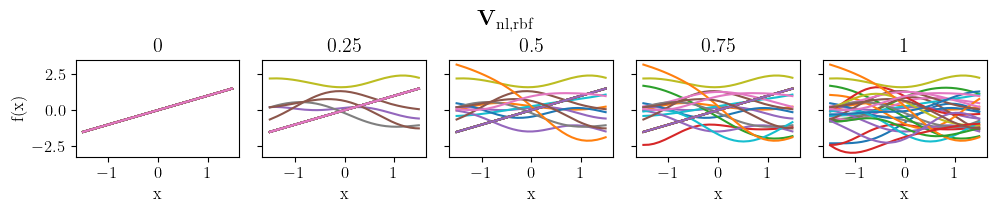

In [3]:
fig, axs  = plt.subplots(1, 5, figsize=(10, 2),sharey=True)
for i, x in enumerate([0,0.25,0.5,0.75,1]):
    sampler = instantiate(cfg["generator"]["lagged"]["nl_sampler"], nl_mode="rbf", limit_startx=[-20.0, 20.0])
    funcs, names = sampler.sample_nl_relationships(np.ones((3,3,3)), nl_proba=x, nl_mask=None)
    for v in range(funcs.shape[0]):
        for w in range(funcs.shape[1]):
            for z in range(funcs.shape[2]):
                axs[i].plot(np.arange(-1.5,1.5,0.01),[funcs[v][w][z](x) for x in np.arange(-1.5,1.5,0.01)])
    axs[i].set_title(f"{x}")
    axs[i].set_xlabel("x")
    
axs[0].set_ylabel("f(x)")
plt.tight_layout()
fig.suptitle(rename_labels["nl_rbf"], fontsize=16, y=1.05)

plt.savefig("../img/RBF_violation.pdf", bbox_inches="tight")

## $V_{nl,comp}$

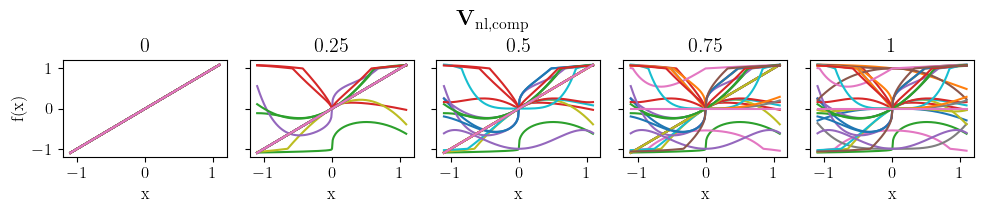

In [5]:
fig, axs  = plt.subplots(1, 5, figsize=(10, 2),sharey=True)
for i, x in enumerate([0,0.25,0.5,0.75,1]):
    sampler = instantiate(cfg["generator"]["lagged"]["nl_sampler"], nl_mode="symbolic", rng=55)
    funcs, names = sampler.sample_nl_relationships(np.ones((3,3,3)), nl_proba=x, nl_mask=None)
    for v in range(funcs.shape[0]):
        for w in range(funcs.shape[1]):
            for z in range(funcs.shape[2]):
                axs[i].plot(np.arange(-1.1,1.1,0.01),[funcs[v][w][z](x) for x in np.arange(-1.1,1.1,0.01)])
    axs[i].set_title(f"{x}")
    axs[i].set_xlabel("x")
    
axs[0].set_ylabel("f(x)")
plt.tight_layout()
fig.suptitle(rename_labels["nl_symbolic"], fontsize=16, y=1.05)
plt.savefig("../img/compose_violation.pdf", bbox_inches="tight")          

# Joint plot

In [3]:
# To keep everything clean we use hydra for HPs.
with initialize(version_base=None, config_path="../../config/generator/lagged/"):
    cfg = compose(config_name='default.yaml')
    
cfg.nl_sampler.which_power_dist = "all"

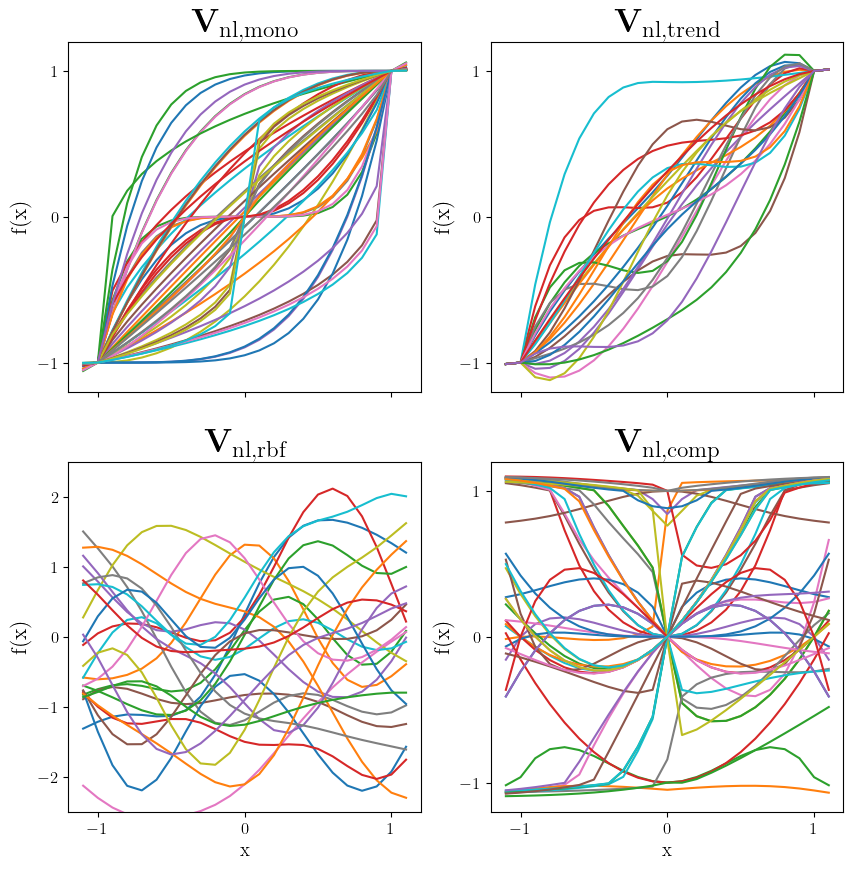

In [8]:

fig, axs  = plt.subplots(2, 2, figsize=(10, 10),sharex=True)
sampler = instantiate(
    cfg["nl_sampler"],
    nl_mode="power_set",
    n_nl_stacking=2,
    rng=55,
    power_dist= [0.125,1,1,8],
    n_options=16,
    rbf_length_scale=2,
    which_power_dist= "all",
    n_nl_operators=1,
    spline_samples=4,
    limit_starty=[-1, 1],
    hard_limity=[-1.1, 1.1],
)
for m in range(50):
    func, name = sampler.sample_nl_relationships(np.ones((5, 5, 3)), 1, None)
    axs[0,0].plot(np.arange(-1.1, 1.2, 0.1),[func[0][0][0](y) for y in np.arange(-1.1, 1.2, 0.1)])

sampler = instantiate(
    cfg["nl_sampler"],
    nl_mode="splines",
    n_nl_stacking=2,
    rng=5,
    power_dist= [0.125,8],
    n_options=16,
    rbf_length_scale=2,
    which_power_dist= "all",
    n_nl_operators=1,
    spline_samples=5,
    limit_starty=[-1, 1],
    hard_limity=[-1.1, 1.1],
)
for m in range(25):
    func, name = sampler.sample_nl_relationships(np.ones((5, 5, 3)), 1, None)
    axs[0,1].plot(np.arange(-1.1, 1.2, 0.1),[func[0][0][0](y) for y in np.arange(-1.1, 1.2, 0.1)])

sampler = instantiate(
    cfg["nl_sampler"],
    nl_mode="rbf",
    rng=54,
    n_nl_stacking=2,
    n_options=16,
    power_dist= [0.125,8],
    rbf_length_scale=0.5,
    which_power_dist= "all",
    n_nl_operators=1,
    spline_samples=4,
    limit_startx=[-2, 2],
    hard_limitx=[-2.1, 2.1],
)
for m in range(25):
    func, name = sampler.sample_nl_relationships(np.ones((5, 5, 3)), 1, None)
    axs[1,0].plot(np.arange(-1.1, 1.2, 0.1),[func[0][0][0](y) for y in np.arange(-1.1, 1.2, 0.1)])
    
sampler = instantiate(
    cfg["nl_sampler"],
    nl_mode="symbolic",
    n_nl_stacking=2,
    n_options=10,
    rng=10,
    power_dist= [0.125,8],
    rbf_length_scale=0.5,
    which_power_dist= "all",
    n_nl_operators=2,
    spline_samples=4,
    limit_starty=[-1, 1],
    hard_limity=[-1.1, 1.1],
)
for m in range(50):
    func, name = sampler.sample_nl_relationships(np.ones((5, 5, 3)), 1, None)
    a = [func[0][0][0](y) for y in np.arange(-4.0, 4.0, 0.1)]
    if np.isnan(a).any():
        break
    axs[1,1].plot(np.arange(-1.1, 1.2, 0.1),[func[0][0][0](y) for y in np.arange(-1.1, 1.2, 0.1)])


name_s = ["Monotonic", "Non-monotonic", "RBF", "Composite"]


def subscript(text):
    # Return a LaTeX string for subscripted text, e.g., V_{ino,auto}
    return r"\textbf{V}_{\mathrm{" + text + r"}}"

rename_labels = {
    # ino
    "Monotonic": rf"${subscript('nl,mono')}$",
    "Non-monotonic": rf"${subscript('nl,trend')}$",
    "RBF": rf"${subscript('nl,rbf')}$",
    "Composite": rf"${subscript('nl,comp')}$",

}

name_s = [rename_labels[x] if x in rename_labels.keys() else x for x in name_s]


for n,subplot_ax in enumerate(axs.flatten()):
    subplot_ax.set_xlim([-1.0, 1.0])
    subplot_ax.set_title(name_s[n], fontsize=24, fontweight='bold')
    subplot_ax.set_xticks([-1.0, 0, 1.0])
    subplot_ax.set_ylabel("f(x)", fontsize=16, fontweight='bold')
    subplot_ax.set_yticks([-1.0, 0, 1.0])
    subplot_ax.set_ylim([-1.2, 1.2])
    subplot_ax.set_xlim([-1.2, 1.2])

    subplot_ax.set_xlabel("x", fontsize=14)
    
axs[1,0].set_ylim([-2.5, 2.5])
axs[1,0].set_yticks([-2,-1.0, 0, 1.0,2])
axs[0,0].set_xlabel("")
axs[0,1].set_xlabel("")


    
plt.savefig("../img/nl_joint.pdf", bbox_inches="tight", dpi=300)